<a href="https://colab.research.google.com/github/ruveydakarakoyun/APTOS-2019/blob/main/aptos_2019.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Veri Yükleme ve Kütüphaneleri Yükleme

In [7]:
import torch

print("PyTorch Versiyonu:", torch.__version__)
print("Mac M2 GPU (MPS) Kullanılabilir mi?:", torch.backends.mps.is_available())

PyTorch Versiyonu: 2.14.0
Mac M2 GPU (MPS) Kullanılabilir mi?: True


In [8]:
import torch

# Mac M2 (MPS), Nvidia (CUDA) ve CPU dinamik cihaz ataması
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("🚀 Aktif Cihaz: Mac M2 Pro GPU (MPS)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"🚀 Aktif Cihaz: Nvidia GPU ({torch.cuda.get_device_name(0)})")
else:
    device = torch.device("cpu")
    print("⚠️ Aktif Cihaz: CPU")

🚀 Aktif Cihaz: Mac M2 Pro GPU (MPS)


In [9]:
!pip install torchvision opencv-python google-cloud-storage google-cloud-bigquery timm albumentations


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [10]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from google.cloud import bigquery, storage

# Proje ve Bucket Bilgileri
PROJECT_ID = "datascience-project-id"
BUCKET_NAME = "aptos2019-retina-images-ds"

print("✅ Bağlantı ve kütüphaneler hazır!")

✅ Bağlantı ve kütüphaneler hazır!


###BigQuery'den Tabloları Çekme

In [11]:
import os
from google.cloud import bigquery, storage
from google.oauth2 import service_account

# ==============================================================================
# KIMLIK DOGRULAMA (KULLANILACAK KOD)
# ==============================================================================
# İndirilenler klasöründeki dolu JSON dosyasının doğrudan yolu
json_path = "/Users/cerenkocabas/Downloads/datascientis-926611d25607.json"

# Credentials nesnesini yüklüyoruz
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = json_path
credentials = service_account.Credentials.from_service_account_file(json_path)

# ==============================================================================
# PROJE GENEL YAPILANDIRMASI (CONFIG) - GÜNCELLENDİ
# ==============================================================================
GCP_PROJECT_ID = "datascientis"
GCS_BUCKET_NAME = "aptos2019-retina-images-ds"
BIGQUERY_DATASET = "APTOS_2019"

# Bucket içindeki güncel klasör yolları (Prefix)
PATH_PREFIXES = {
    "train": "aptos2019-retina-images/aptos_train_images/",
    "valid": "aptos2019-retina-images/aptos_valid_images/",
    "validation": "aptos2019-retina-images/aptos_valid_images/",
    "test": "aptos2019-retina-images/aptos_test_images/",
}

# BigQuery tablo yolları
BQ_TABLES = {
    "train": f"{GCP_PROJECT_ID}.{BIGQUERY_DATASET}.aptos_train",
    "valid": f"{GCP_PROJECT_ID}.{BIGQUERY_DATASET}.aptos_valid",
    "test":  f"{GCP_PROJECT_ID}.{BIGQUERY_DATASET}.aptos_test"
}

# ==============================================================================
# BİGQUERY'DEN VERİLERİ ÇEKME
# ==============================================================================
bq_client = bigquery.Client(project=GCP_PROJECT_ID, credentials=credentials)
storage_client = storage.Client(project=GCP_PROJECT_ID, credentials=credentials)

# BigQuery sorguları
query_train = f"SELECT id_code, diagnosis, image_file FROM `{BQ_TABLES['train']}`"
query_valid = f"SELECT id_code, diagnosis, image_file FROM `{BQ_TABLES['valid']}`"
query_test  = f"SELECT id_code, diagnosis, image_file FROM `{BQ_TABLES['test']}`"

df_train = bq_client.query(query_train).to_dataframe()
df_valid = bq_client.query(query_valid).to_dataframe()
df_test  = bq_client.query(query_test).to_dataframe()

print(f"📊 Train Veri Sayısı : {len(df_train)}")
print(f"📊 Valid Veri Sayısı : {len(df_valid)}")
print(f"📊 Test Veri Sayısı  : {len(df_test)}")

/Users/cerenkocabas/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
/Users/cerenkocabas/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
/Users/cerenkocabas/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


📊 Train Veri Sayısı : 2930
📊 Valid Veri Sayısı : 366
📊 Test Veri Sayısı  : 366


In [18]:
import io
import torch
from torch.utils.data import Dataset
from PIL import Image
from google.cloud import storage

class APTOSDataset(Dataset):
    def __init__(self, df, bucket_name, project_id, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

        # 🔑 KRİTİK NOKTA: GCS istemcisi SADECE 1 KERE burada oluşturulur.
        # Her resim için baştan istemci kurulmaz!
        self.client = storage.Client(project=project_id)
        self.bucket = self.client.bucket(bucket_name)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Görsel yolunu al (id_code veya image_path)
        img_name = row['id_code'] if 'id_code' in row else row['image_id']

        # Eğer uzantı yoksa .png ekle
        if not img_name.endswith('.png') and not img_name.endswith('.jpg'):
            img_name = f"{img_name}.png"

        # Blob üzerinden doğrudan byte olarak okuma (en hızlı yöntem)
        blob = self.bucket.blob(f"train_images/{img_name}")
        image_bytes = blob.download_as_bytes()

        # PIL Image dönüştürme
        image = Image.open(io.BytesIO(image_bytes)).convert('RGB')

        if self.transform:
            image = self.transform(image)

        # Etiket (diagnosis)
        label = torch.tensor(row['diagnosis'], dtype=torch.long)

        return image, label

###Dataframe'leri ve Transform'ları Ayırma

In [19]:
import torchvision.transforms as T
from torch.utils.data import DataLoader

# Proje ve Bucket Bilgileri (GCP yapılandırmanızla birebir aynı)
PROJECT_ID = "datascientis"
BUCKET_NAME = "aptos2019-retina-images-ds"

# Transform tanımları
train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Dataset ve DataLoader nesneleri
train_dataset = APTOSDataset(df_train, BUCKET_NAME, PROJECT_ID, transform=train_transform)
valid_dataset = APTOSDataset(df_valid, BUCKET_NAME, PROJECT_ID, transform=eval_transform)
test_dataset  = APTOSDataset(df_test,  BUCKET_NAME, PROJECT_ID, transform=eval_transform)

# num_workers=0 ve pin_memory=True (M2 Mac ve GCS akışı için optimize edildi)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

print("✅ DataLoader bağlantıları yenilendi!")

✅ DataLoader bağlantıları yenilendi!


#EDA

###Sınıf dağılımı (Evre 0 - Evre 4 kaçar adet?) grafikleri ve Sınıf dengesizliği oranları


📊 Train Sınıf Dağılımı


,Evre,Sınıf,Görüntü Sayısı,Yüzde (%)
0,0,No DR,1434,48.94
1,1,Mild,300,10.24
2,2,Moderate,808,27.58
3,3,Severe,154,5.26
4,4,Proliferative DR,234,7.99


En fazla görüntü : Evre 0 (No DR) → 1434
En az görüntü   : Evre 3 (Severe) → 154
Sınıf dengesizlik oranı (Max / Min): 9.31


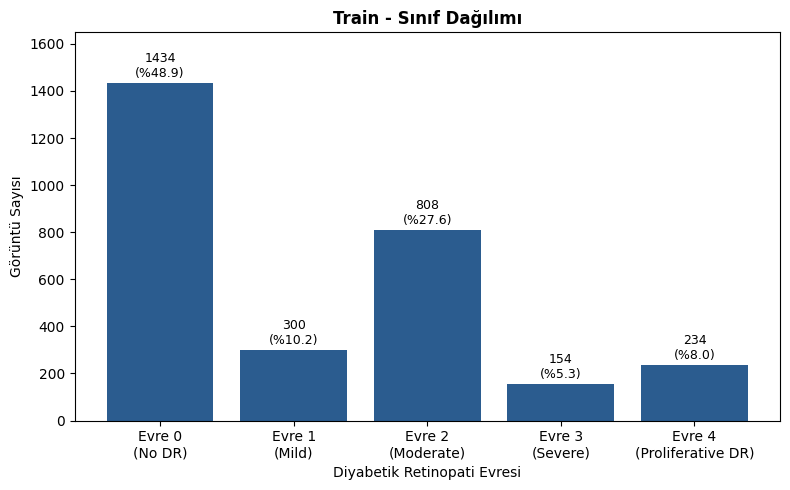


📊 Validation Sınıf Dağılımı


,Evre,Sınıf,Görüntü Sayısı,Yüzde (%)
0,0,No DR,172,46.99
1,1,Mild,40,10.93
2,2,Moderate,104,28.42
3,3,Severe,22,6.01
4,4,Proliferative DR,28,7.65


En fazla görüntü : Evre 0 (No DR) → 172
En az görüntü   : Evre 3 (Severe) → 22
Sınıf dengesizlik oranı (Max / Min): 7.82


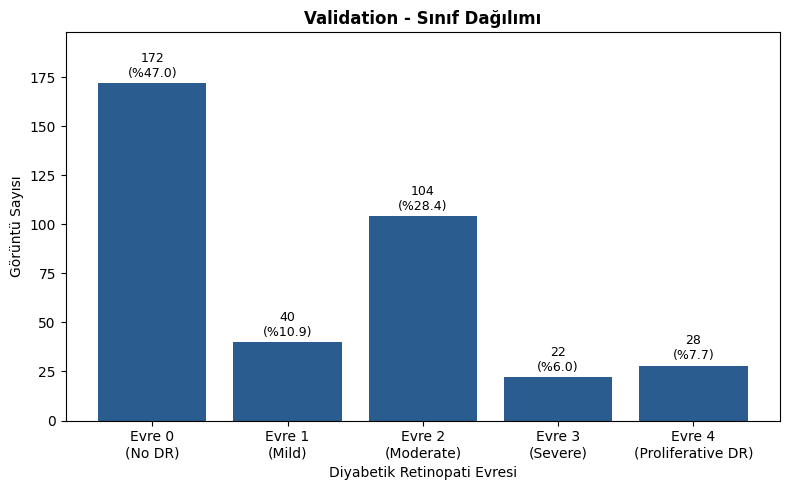


📊 Test Sınıf Dağılımı


,Evre,Sınıf,Görüntü Sayısı,Yüzde (%)
0,0,No DR,199,54.37
1,1,Mild,30,8.2
2,2,Moderate,87,23.77
3,3,Severe,17,4.64
4,4,Proliferative DR,33,9.02


En fazla görüntü : Evre 0 (No DR) → 199
En az görüntü   : Evre 3 (Severe) → 17
Sınıf dengesizlik oranı (Max / Min): 11.71


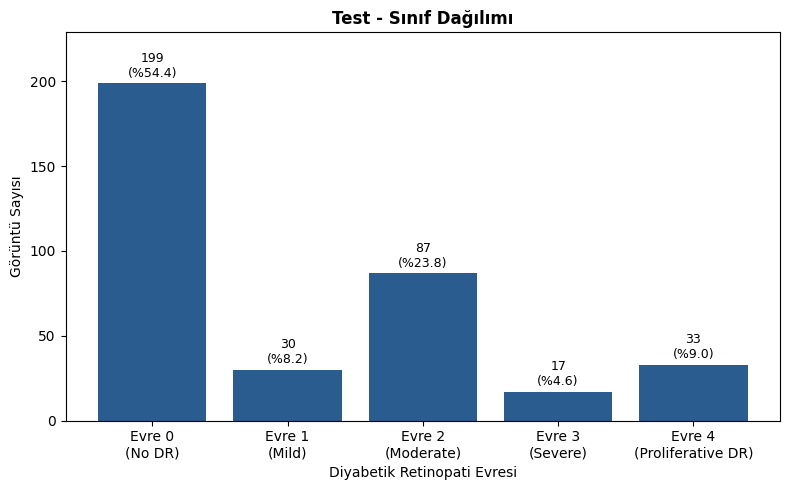

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Sınıf isimleri
class_names = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR",
}

datasets = {"Train": df_train, "Validation": df_valid, "Test": df_test}

for dataset_name, df in datasets.items():
    # Her sınıftaki görüntü sayısı
    counts = (
        df["diagnosis"]
        .value_counts()
        .reindex(range(5), fill_value=0)
        .sort_index()
    )

    # Yüzdelik dağılım
    percentages = (counts / counts.sum()) * 100

    # Sonuç tablosu
    distribution_table = pd.DataFrame({
        "Evre": counts.index,
        "Sınıf": [class_names[i] for i in counts.index],
        "Görüntü Sayısı": counts.values,
        "Yüzde (%)": percentages.round(2).values,
    })

    print(f"\n📊 {dataset_name} Sınıf Dağılımı")
    display(distribution_table)

    # Sınıf dengesizliği
    non_zero_counts = counts[counts > 0]
    max_count = non_zero_counts.max()
    min_count = non_zero_counts.min()
    imbalance_ratio = max_count / min_count

    print(
        f"En fazla görüntü : Evre {non_zero_counts.idxmax()} ({class_names[non_zero_counts.idxmax()]}) → {max_count}"
    )
    print(
        f"En az görüntü   : Evre {non_zero_counts.idxmin()} ({class_names[non_zero_counts.idxmin()]}) → {min_count}"
    )
    print(f"Sınıf dengesizlik oranı (Max / Min): {imbalance_ratio:.2f}")

    # Grafik
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(
        [f"Evre {i}\n({class_names[i]})" for i in counts.index],
        counts.values,
        color="#2b5c8f",
    )

    ax.set_title(
        f"{dataset_name} - Sınıf Dağılımı", fontsize=12, fontweight="bold"
    )
    ax.set_xlabel("Diyabetik Retinopati Evresi", fontsize=10)
    ax.set_ylabel("Görüntü Sayısı", fontsize=10)

    # Grafik üst limitini yazılar sığsın diye biraz artırıyoruz
    ax.set_ylim(0, max_count * 1.15)

    for bar, count, percentage in zip(bars, counts.values, percentages.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (max_count * 0.01),
            f"{count}\n(%{percentage:.1f})",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()
    plt.close(fig)  # Bellek temizliği

 ### Ham retina resimlerinin piksel boyutları, çözünürlükleri ve renk kanalları (RGB/Grayscale) kontrol edilir.

In [50]:
import io
from google.cloud import storage
from google.oauth2 import service_account
from IPython.display import display
import pandas as pd

# GCP Bağlantısı
JSON_PATH = "/Users/cerenkocabas/Downloads/datascientis-926611d25607.json"
GCP_PROJECT_ID = "datascientis"
GCS_BUCKET_NAME = "aptos2019-retina-images-ds"

credentials = service_account.Credentials.from_service_account_file(JSON_PATH)
storage_client = storage.Client(
    project=GCP_PROJECT_ID, credentials=credentials
)
bucket = storage_client.bucket(GCS_BUCKET_NAME)

# Colab'in ürettiği final raporu oku
FINAL_PATH = "eda_cache/image_properties.csv"
final_blob = bucket.blob(FINAL_PATH)

if final_blob.exists():
    csv_bytes = final_blob.download_as_bytes()
    image_properties_df = pd.read_csv(io.BytesIO(csv_bytes))

    print("✅ Colab tarafından tamamlanan tam EDA raporu yüklendi!")
    print(f"Toplam Kayıt           : {len(image_properties_df)}")
    print(
        f"Başarılı Okunan Görüntü: {(image_properties_df['status'] == 'ok').sum()}"
    )

    # İstatistiksel özetler
    valid_df = image_properties_df.dropna(subset=["width", "height"]).copy()
    valid_df["width"] = valid_df["width"].astype(int)
    valid_df["height"] = valid_df["height"].astype(int)

    print("\n📐 GÖRÜNTÜ BOYUTLARI")
    display(valid_df[["width", "height"]].describe())

    print("\n🖼️ EN SIK GÖRÜLEN 10 ÇÖZÜNÜRLÜK")
    display(valid_df["resolution"].value_counts().head(10))
else:
    print(
        "❌ Final dosyası bulunamadı, Colab üzerindeki kaydın tamamlandığından emin olun."
    )

✅ Colab tarafından tamamlanan tam EDA raporu yüklendi!
Toplam Kayıt           : 3662
Başarılı Okunan Görüntü: 3662

📐 GÖRÜNTÜ BOYUTLARI


,width,height
count,3662.000000,3662.000000
mean,2015.176679,1526.830147
std,884.301940,542.663120
min,474.000000,358.000000
25%,1050.000000,1050.000000
50%,2144.000000,1536.000000
75%,2588.000000,1958.000000
max,4288.000000,2848.000000



🖼️ EN SIK GÖRÜLEN 10 ÇÖZÜNÜRLÜK


resolution
1050x1050    974
2416x1736    638
2588x1958    533
3216x2136    410
2048x1536    351
819x614      287
3388x2588    141
1504x1000     92
1844x1226     61
4288x2848     52
Name: count, dtype: int64

In [51]:
# Ham görüntü analizi özeti

print("📐 GÖRÜNTÜ BOYUTLARI")
display(
    image_properties_df[["width", "height"]].describe()
)

print("\n🖼️ TOPLAM FARKLI ÇÖZÜNÜRLÜK SAYISI")
print(image_properties_df["resolution"].nunique())

print("\n🖼️ EN SIK GÖRÜLEN 10 ÇÖZÜNÜRLÜK")
display(
    image_properties_df["resolution"]
    .value_counts()
    .head(10)
)

print("\n🎨 RENK MODLARI")
display(
    image_properties_df["color_mode"].value_counts()
)

print("\n📺 KANAL SAYILARI")
display(
    image_properties_df["channels"].value_counts()
)

📐 GÖRÜNTÜ BOYUTLARI


,width,height
count,3662.000000,3662.000000
mean,2015.176679,1526.830147
std,884.301940,542.663120
min,474.000000,358.000000
25%,1050.000000,1050.000000
50%,2144.000000,1536.000000
75%,2588.000000,1958.000000
max,4288.000000,2848.000000



🖼️ TOPLAM FARKLI ÇÖZÜNÜRLÜK SAYISI
17

🖼️ EN SIK GÖRÜLEN 10 ÇÖZÜNÜRLÜK


resolution
1050x1050    974
2416x1736    638
2588x1958    533
3216x2136    410
2048x1536    351
819x614      287
3388x2588    141
1504x1000     92
1844x1226     61
4288x2848     52
Name: count, dtype: int64


🎨 RENK MODLARI


color_mode
RGB    3662
Name: count, dtype: int64


📺 KANAL SAYILARI


channels
3    3662
Name: count, dtype: int64

Ham retina görüntülerinin çözünürlüklerinin sabit olmadığı ve veri setinde 17 farklı çözünürlük bulunduğu görülmüştür. Görüntü boyutları 474×358 ile 4288×2848 arasında değişmektedir. Tüm 3662 görüntünün RGB formatında ve 3 kanallı olduğu doğrulanmıştır. Bu nedenle modelleme öncesinde görüntülerin ortak bir boyuta yeniden ölçeklendirilmesi gerekmektedir.

###Veri Temizleme ve Kalite Kontrol Betiği

Bozuk, açılmayan veya aşırı karanlık görseller için hızlı bir veri temizleme kontrol betiği

In [16]:
import io
from concurrent.futures import ThreadPoolExecutor
from google.cloud import storage
from google.oauth2 import service_account
import pandas as pd  # <--- EKLENDİ
from PIL import Image, ImageStat
from tqdm.auto import tqdm

# Credentials nesnesi
json_path = "/Users/cerenkocabas/Downloads/datascientis-926611d25607.json"
credentials = service_account.Credentials.from_service_account_file(json_path)


def verify_single_image(row, bucket, folder_prefix, brightness_threshold):
    img_file = (
        row["image_file"]
        if "image_file" in row and pd.notnull(row["image_file"])
        else f"{row['id_code']}.png"
    )
    full_blob_path = f"{folder_prefix}{img_file}"

    try:
        blob = bucket.blob(full_blob_path)
        image_bytes = blob.download_as_bytes()
        img = Image.open(io.BytesIO(image_bytes)).convert("RGB")

        # Parlaklık hesabı (Grayscale dönüşümü üzerinden ortalama piksel değeri)
        stat = ImageStat.Stat(img.convert("L"))
        mean_brightness = stat.mean[0]

        if mean_brightness < brightness_threshold:
            return ("dark", row["id_code"], full_blob_path, mean_brightness)
        else:
            return ("valid", row.name, None, None)

    except Exception as e:
        return ("corrupted", row["id_code"], full_blob_path, str(e))


def check_dataset_quality_fast(
    df,
    bucket_name,
    project_id,
    folder_prefix="",
    brightness_threshold=12.0,
    max_workers=20,
):
    print(
        f"🚀 '{folder_prefix}' klasörü {max_workers} eşzamanlı kanaldan kontrol ediliyor...\n"
    )

    storage_client = storage.Client(
        project=project_id, credentials=credentials
    )
    bucket = storage_client.bucket(bucket_name)

    corrupted_images = []
    too_dark_images = []
    valid_indices = []

    rows = [row for _, row in df.iterrows()]

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        # executor.map kullanarak memory leaks riskini önlüyoruz
        results = list(
            tqdm(
                executor.map(
                    lambda r: verify_single_image(
                        r, bucket, folder_prefix, brightness_threshold
                    ),
                    rows,
                ),
                total=len(rows),
                desc="Görseller Analiz Ediliyor",
            )
        )

    for status, arg1, arg2, arg3 in results:
        if status == "valid":
            valid_indices.append(arg1)
        elif status == "dark":
            too_dark_images.append(
                {"id_code": arg1, "path": arg2, "brightness": arg3}
            )
        elif status == "corrupted":
            corrupted_images.append(
                {"id_code": arg1, "path": arg2, "error": arg3}
            )

    print("\n" + "=" * 40)
    print("📋 HIZLANDIRILMIŞ KONTROL SONUÇLARI RAPORU")
    print("=" * 40)
    print(f"✅ Sağlam ve Geçerli Görsel Sayısı : {len(valid_indices)}")
    print(f"❌ Bozuk / Bulunamayan Görsel Sayısı: {len(corrupted_images)}")
    print(f"⚠️  Aşırı Karanlık Görsel Sayısı  : {len(too_dark_images)}")

    return valid_indices, corrupted_images, too_dark_images


# --- TESTİ BAŞLAT ---
valid_idx, corrupted_list, dark_list = check_dataset_quality_fast(
    df=df_train,
    bucket_name=GCS_BUCKET_NAME,
    project_id=GCP_PROJECT_ID,
    folder_prefix=PATH_PREFIXES["train"],
    max_workers=20,
)

🚀 'aptos2019-retina-images/aptos_train_images/' klasörü 20 eşzamanlı kanaldan kontrol ediliyor...



Görseller Analiz Ediliyor:   0%|          | 0/2930 [00:00<?, ?it/s]


📋 HIZLANDIRILMIŞ KONTROL SONUÇLARI RAPORU
✅ Sağlam ve Geçerli Görsel Sayısı : 2930
❌ Bozuk / Bulunamayan Görsel Sayısı: 0
⚠️  Aşırı Karanlık Görsel Sayısı  : 0


### Göz etrafındaki siyah boşlukları otomatik kesen Auto-Crop uygulama.

Orijinal boyut: (614, 819, 3)
Crop sonrası boyut: (614, 770, 3)


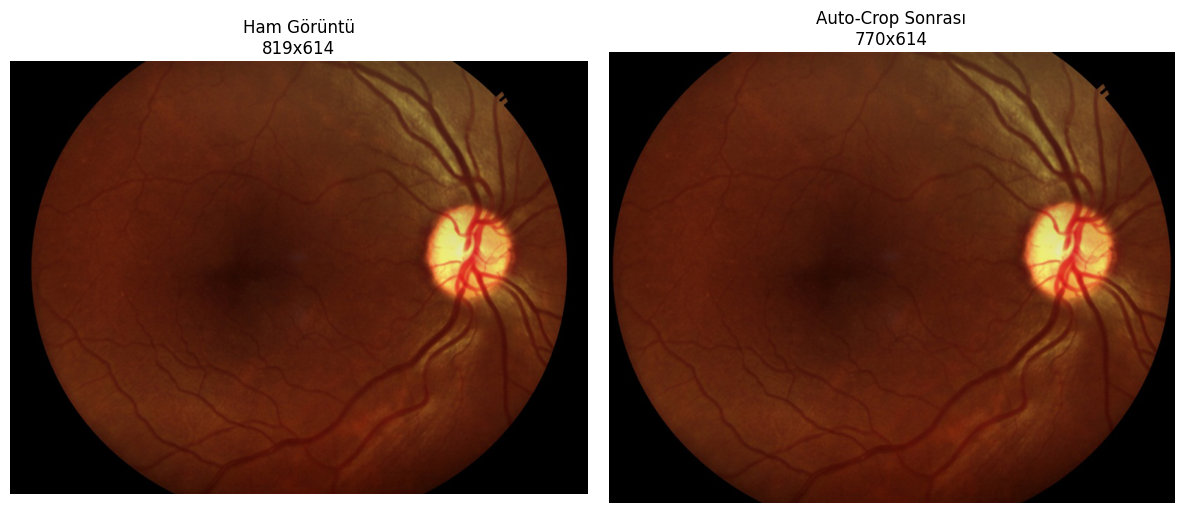

In [21]:
import io
import cv2
from google.cloud import storage
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms

# ==============================================================================
# PROJE YAPILANDIRMASI (SIFIR GİZLİ DOSYA YOLU)
# ==============================================================================
GCP_PROJECT_ID = "datascientis"
GCS_BUCKET_NAME = "aptos2019-retina-images-ds"

# Sistemdeki varsayılan yetkiyi otomatik kullanır
storage_client = storage.Client(project=GCP_PROJECT_ID)
bucket = storage_client.bucket(GCS_BUCKET_NAME)

PATH_PREFIXES = {
    "train": "aptos2019-retina-images/aptos_train_images/",
    "valid": "aptos2019-retina-images/aptos_valid_images/",
    "test": "aptos2019-retina-images/aptos_test_images/",
}


# ==============================================================================
# 1. ADIM: Auto-Crop Fonksiyonu
# ==============================================================================
def auto_crop(image, threshold=10, padding=5):
    if isinstance(image, Image.Image):
        image = np.array(image)

    gray = (
        cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        if len(image.shape) == 3
        else image
    )
    mask = gray > threshold

    if not np.any(mask):
        return image

    y_coords, x_coords = np.where(mask)
    x_min, y_min = max(0, x_coords.min() - padding), max(
        0, y_coords.min() - padding
    )
    x_max, y_max = min(image.shape[1], x_coords.max() + padding + 1), min(
        image.shape[0], y_coords.max() + padding + 1
    )

    cropped = image[y_min:y_max, x_min:x_max]

    # Güvenlik eşiği (%10 altı kırpılmayı engelle)
    if (
        cropped.shape[0] < image.shape[0] * 0.1
        or cropped.shape[1] < image.shape[1] * 0.1
    ):
        return image

    return cropped


# ==============================================================================
# 2. ADIM: APTOSDataset Sınıfı
# ==============================================================================
class APTOSDataset(Dataset):

    def __init__(
        self, df, bucket_name, project_id, folder_prefix="", transform=None
    ):
        self.df = df.reset_index(drop=True)
        self.bucket_name = bucket_name
        self.project_id = project_id
        self.folder_prefix = folder_prefix
        self.transform = transform
        self._bucket = None

    @property
    def bucket(self):
        if self._bucket is None:
            client = storage.Client(project=self.project_id)
            self._bucket = client.bucket(self.bucket_name)
        return self._bucket

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_file = (
            row["image_file"]
            if "image_file" in row and pd.notnull(row["image_file"])
            else f"{row['id_code']}.png"
        )
        label = (
            int(row["diagnosis"])
            if "diagnosis" in row and pd.notnull(row["diagnosis"])
            else -1
        )

        full_blob_path = f"{self.folder_prefix}{img_file}"

        try:
            blob = self.bucket.blob(full_blob_path)
            image_bytes = blob.download_as_bytes()
            img_pil = Image.open(io.BytesIO(image_bytes)).convert("RGB")
            img_cropped = auto_crop(np.array(img_pil), threshold=10, padding=5)
            img_final = Image.fromarray(img_cropped)
        except Exception:
            img_final = Image.new("RGB", (224, 224), (0, 0, 0))

        img_tensor = (
            self.transform(img_final)
            if self.transform
            else transforms.ToTensor()(img_final)
        )
        return img_tensor, torch.tensor(label, dtype=torch.long)


# ==============================================================================
# 3. & 4. ADIM: Test ve Görselleştirme
# ==============================================================================
test_row = df_train.iloc[0]
test_id = str(test_row["id_code"])
img_file = (
    test_row["image_file"]
    if "image_file" in test_row and pd.notnull(test_row["image_file"])
    else f"{test_id}.png"
)

blob_path = f"{PATH_PREFIXES['train']}{img_file}"
blob = bucket.blob(blob_path)
image_bytes = blob.download_as_bytes()

img_pil = Image.open(io.BytesIO(image_bytes)).convert("RGB")
original_image = np.array(img_pil)
cropped_image = auto_crop(original_image)

print("Orijinal boyut:", original_image.shape)
print("Crop sonrası boyut:", cropped_image.shape)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(original_image)
plt.title(f"Ham Görüntü\n{original_image.shape[1]}x{original_image.shape[0]}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cropped_image)
plt.title(
    f"Auto-Crop Sonrası\n{cropped_image.shape[1]}x{cropped_image.shape[0]}"
)
plt.axis("off")

plt.tight_layout()
plt.show()

CLAHE :Kılcal damarları netleştirmek için CLAHE (Kontrast Artırma) algoritması kodlanır ve görsellere uygulanır

Auto-Crop görüntü boyutu: (614, 770, 3)
CLAHE görüntü boyutu    : (614, 770, 3)


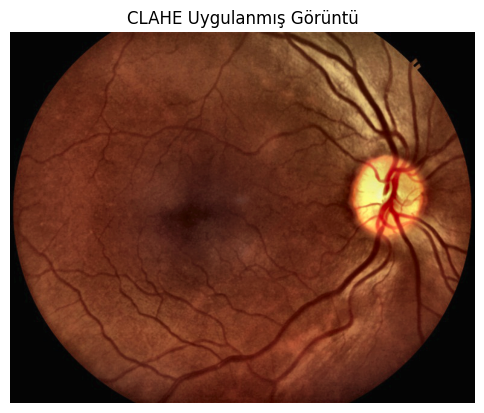

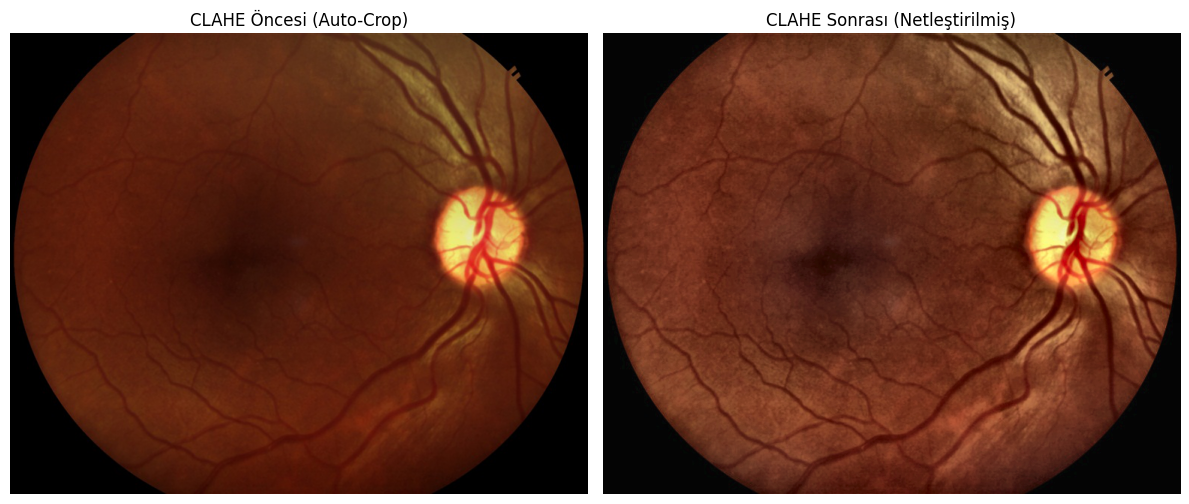

In [22]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


# ==============================================================================
# 1. CLAHE FONKSİYONU
# Retina görüntüsünde lokal kontrastı artırır
# ==============================================================================
def apply_clahe(image, clip_limit=2.0, tile_grid_size=(8, 8)):
    # RGB -> LAB
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    # L, A, B kanallarını ayır
    l, a, b = cv2.split(lab)

    # CLAHE oluştur
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    # Sadece parlaklık (L) kanalına CLAHE uygula
    l_clahe = clahe.apply(l)

    # Kanalları tekrar birleştir
    lab_clahe = cv2.merge((l_clahe, a, b))

    # LAB -> RGB
    enhanced_image = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)

    return enhanced_image


# ==============================================================================
# 2. KARŞILAŞTIRMA FONKSİYONU
# CLAHE öncesi ve sonrası görüntüleri yan yana çizer
# ==============================================================================
def compare_clahe(before_image, after_image):
    plt.figure(figsize=(12, 5))

    # CLAHE öncesi
    plt.subplot(1, 2, 1)
    plt.imshow(before_image)
    plt.title("CLAHE Öncesi (Auto-Crop)")
    plt.axis("off")

    # CLAHE sonrası
    plt.subplot(1, 2, 2)
    plt.imshow(after_image)
    plt.title("CLAHE Sonrası (Netleştirilmiş)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# ==============================================================================
# 3. UYGULAMA VE BOYUT KONTROLÜ
# ==============================================================================
# CLAHE uygulama
clahe_image = apply_clahe(cropped_image)

# Boyut Kontrolleri
print("Auto-Crop görüntü boyutu:", cropped_image.shape)
print("CLAHE görüntü boyutu    :", clahe_image.shape)

# Tekli Görselleştirme
plt.figure(figsize=(6, 6))
plt.imshow(clahe_image)
plt.title("CLAHE Uygulanmış Görüntü")
plt.axis("off")
plt.show()

# Karşılaştırmalı Görselleştirme
compare_clahe(cropped_image, clahe_image)

# PyTorch Dataset & Data Augmentation

### Albumentations kütüphanesi kullanılarak rastgele döndürme (rotation), yatay/dikey çevirme (flip) gibi Data Augmentation süreçleri (Eğitim (train) veri setinde çeşitliliği artırmak için güçlü dönüşümler eklerken, doğrulama (valid) veri setinde resimlerin orijinal yapısını koruyup sadece boyutlandırma ve normalize etme işlemleri uyguluyoruz)

In [23]:
import io
from google.cloud import storage
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset


class APTOSDataset(Dataset):

    def __init__(
        self, df, bucket_name, project_id, folder_prefix="", transform=None
    ):
        self.df = df.reset_index(drop=True)
        self.bucket_name = bucket_name
        self.project_id = project_id
        self.folder_prefix = folder_prefix
        self.transform = transform
        self._bucket = None

    @property
    def bucket(self):
        if self._bucket is None:
            client = storage.Client(project=self.project_id)
            self._bucket = client.bucket(self.bucket_name)
        return self._bucket

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_file = (
            row["image_file"]
            if "image_file" in row and pd.notnull(row["image_file"])
            else f"{row['id_code']}.png"
        )
        label = (
            int(row["diagnosis"])
            if "diagnosis" in row and pd.notnull(row["diagnosis"])
            else -1
        )

        full_blob_path = f"{self.folder_prefix}{img_file}"

        try:
            blob = self.bucket.blob(full_blob_path)
            image_bytes = blob.download_as_bytes()

            # 1. PIL -> NumPy
            img_pil = Image.open(io.BytesIO(image_bytes)).convert("RGB")
            img_np = np.array(img_pil)

            # 2. Auto-Crop Uygulaması
            img_cropped = auto_crop(img_np, threshold=10, padding=5)

            # 3. CLAHE Uygulaması (Kılcal damarları netleştirme)
            img_final = apply_clahe(img_cropped)

        except Exception:
            # Okuma hatasında 224x224 siyah görüntü fallback'i
            img_final = np.zeros((224, 224, 3), dtype=np.uint8)

        # 4. Albumentations Dönüşümü
        if self.transform:
            augmented = self.transform(image=img_final)
            img_tensor = augmented["image"]
        else:
            img_tensor = (
                torch.from_numpy(img_final).permute(2, 0, 1).float() / 255.0
            )

        return img_tensor, torch.tensor(label, dtype=torch.long)

In [24]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader

# 1. Transform Tanımları
train_transform = A.Compose(
    [
        A.Resize(224, 224),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5
        ),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)

val_transform = A.Compose(
    [
        A.Resize(224, 224),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)

# 2. Dataset ve DataLoader Oluşturma
train_dataset = APTOSDataset(
    df=df_train,
    bucket_name=GCS_BUCKET_NAME,
    project_id=GCP_PROJECT_ID,
    folder_prefix=PATH_PREFIXES["train"],
    transform=train_transform,
)

train_loader = DataLoader(
    train_dataset, batch_size=16, shuffle=True, num_workers=0
)

# 3. İlk Batch Kontrolü
images, labels = next(iter(train_loader))

print("✅ Albumentations Entegrasyonu Başarılı!")
print(f"📦 Batch Görüntü Şekli (Tensor) : {images.shape}")  # [16, 3, 224, 224]
print(f"🏷️ Batch Etiket Şekli (Tensor)  : {labels.shape}")  # [16]
print(f"📊 Veri Tipi                    : {images.dtype}")  # torch.float32

/Users/cerenkocabas/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


✅ Albumentations Entegrasyonu Başarılı!
📦 Batch Görüntü Şekli (Tensor) : torch.Size([16, 3, 224, 224])
🏷️ Batch Etiket Şekli (Tensor)  : torch.Size([16])
📊 Veri Tipi                    : torch.float32


** Albumentations kütüphanesi standart PIL görselleri yerine NumPy dizileri (np.ndarray) ile çalışır. Bu yüzden __getitem__ içinde kırpma işleminden sonra resmi NumPy formatında tutup transform(image=img_cropped) şeklinde çağırmamız gerekir

In [25]:
import io
from google.cloud import storage
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset


class APTOSDataset(Dataset):

    def __init__(
        self, df, bucket_name, project_id, folder_prefix="", transform=None
    ):
        self.df = df.reset_index(drop=True)
        self.bucket_name = bucket_name
        self.project_id = project_id
        self.folder_prefix = folder_prefix
        self.transform = transform
        self._bucket = None

    @property
    def bucket(self):
        # DataLoader worker süreçlerinde çökme yaşamamak için lazy connection
        if self._bucket is None:
            client = storage.Client(project=self.project_id)
            self._bucket = client.bucket(self.bucket_name)
        return self._bucket

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_file = (
            row["image_file"]
            if "image_file" in row and pd.notnull(row["image_file"])
            else f"{row['id_code']}.png"
        )
        label = (
            int(row["diagnosis"])
            if "diagnosis" in row and pd.notnull(row["diagnosis"])
            else -1
        )

        # 1. GCS'den resmi okuma
        full_blob_path = f"{self.folder_prefix}{img_file}"

        try:
            blob = self.bucket.blob(full_blob_path)
            image_bytes = blob.download_as_bytes()

            # 2. PIL -> NumPy (Albumentations için np.ndarray şarttır)
            img_pil = Image.open(io.BytesIO(image_bytes)).convert("RGB")
            img_np = np.array(img_pil)

            # 3. Kırpma işlemi (Auto-Crop)
            img_cropped = auto_crop(img_np, threshold=10, padding=5)

            # 4. Kılcal Damarları Netleştirme (CLAHE) - EKLENDİ
            img_final = apply_clahe(img_cropped)

        except Exception:
            # Görsel okuma hatası olursa 224x224 siyah görüntü oluştur
            img_final = np.zeros((224, 224, 3), dtype=np.uint8)

        # 5. Albumentations Augmentation Uygulama
        if self.transform:
            # Albumentations NumPy dizisi (uint8) bekler
            augmented = self.transform(image=img_final)
            img_tensor = augmented["image"]
        else:
            # Dönüşüm yoksa varsayılan PyTorch tensor formatı [C, H, W]
            img_tensor = (
                torch.from_numpy(img_final).permute(2, 0, 1).float() / 255.0
            )

        return img_tensor, torch.tensor(label, dtype=torch.long)

###PyTorch Dataset ve DataLoader sınıfları kodlanır.

####DataDataLoader'ları Hazırlama

###Eğitim, doğrulama (validation) ve test veri yükleyicilerinin sorunsuz veri beslediği test etme

✅ Train Loader: 2930 resim | 92 batch
✅ Val Loader  : 366 resim | 12 batch
✅ Test Loader : 366 resim | 12 batch

✅ VERİ BORUSU TESTİ BAŞARILI!
• Batch Resim Boyutu (Shape) : torch.Size([32, 3, 224, 224])
• Batch Etiket Boyutu (Shape): torch.Size([32])
• Veri Tipi (Dtype)          : torch.float32
• Etiket Örnekleri (İlk 5)   : [2, 0, 1, 1, 1]


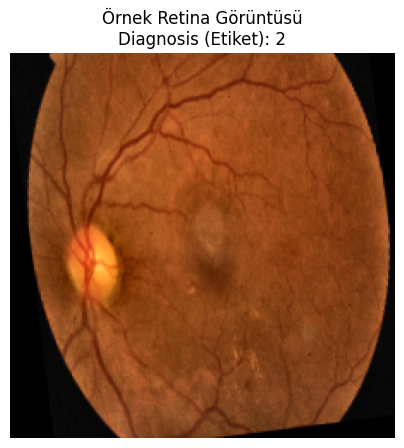

In [26]:
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader

# ==============================================================================
# 1. DATALOADER'LARI TANIMLAMA
# ==============================================================================
# Mac (Apple Silicon) üzerinde çökme/donma yaşamamak için worker tespiti
num_workers = 0

# Train Dataset & Loader
train_dataset = APTOSDataset(
    df=df_train,
    bucket_name=GCS_BUCKET_NAME,
    project_id=GCP_PROJECT_ID,
    folder_prefix=PATH_PREFIXES["train"],
    transform=train_transform,
)

# Validation Dataset & Loader
val_dataset = APTOSDataset(
    df=df_valid,
    bucket_name=GCS_BUCKET_NAME,
    project_id=GCP_PROJECT_ID,
    folder_prefix=PATH_PREFIXES["valid"],
    transform=val_transform,
)

# Test Dataset & Loader
test_dataset = APTOSDataset(
    df=df_test,
    bucket_name=GCS_BUCKET_NAME,
    project_id=GCP_PROJECT_ID,
    folder_prefix=PATH_PREFIXES["test"],
    transform=val_transform,
)

# DataLoader Yükleyicileri (Batch Size: 32)
train_loader = DataLoader(
    train_dataset, batch_size=32, shuffle=True, num_workers=num_workers
)
val_loader = DataLoader(
    val_dataset, batch_size=32, shuffle=False, num_workers=num_workers
)
test_loader = DataLoader(
    test_dataset, batch_size=32, shuffle=False, num_workers=num_workers
)

print(
    f"✅ Train Loader: {len(train_dataset)} resim | {len(train_loader)} batch"
)
print(f"✅ Val Loader  : {len(val_dataset)} resim | {len(val_loader)} batch")
print(f"✅ Test Loader : {len(test_dataset)} resim | {len(test_loader)} batch\n")

# ==============================================================================
# 2. VERİ BORUSU DOĞRULAMA VE GÖRSELLEŞTİRME TESTİ
# ==============================================================================
try:
    # Train Loader'dan ilk batch'i çekelim
    images, labels = next(iter(train_loader))

    print("✅ VERİ BORUSU TESTİ BAŞARILI!")
    print(f"• Batch Resim Boyutu (Shape) : {images.shape}")  # [32, 3, 224, 224]
    print(f"• Batch Etiket Boyutu (Shape): {labels.shape}")  # [32]
    print(f"• Veri Tipi (Dtype)          : {images.dtype}")
    print(f"• Etiket Örnekleri (İlk 5)   : {labels[:5].tolist()}")

    # Resim Un-Normalize İşlemi ([C, H, W] -> [H, W, C])
    sample_img = images[0].permute(1, 2, 0).cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    sample_img = std * sample_img + mean
    sample_img = np.clip(sample_img, 0, 1)

    # Görselleştirme
    plt.figure(figsize=(5, 5))
    plt.imshow(sample_img)
    plt.title(f"Örnek Retina Görüntüsü\nDiagnosis (Etiket): {labels[0].item()}")
    plt.axis("off")
    plt.show()

except Exception as e:
    print("❌ Data Borusu Testinde Hata Oluştu:")
    print(e)

# Model Mimarisi & Kayıp Fonksiyonu (Loss)

## Baseline (temel) basit bir custom CNN veya hafif model mimarisi hazırlama

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(BaselineCNN, self).__init__()

        # 1. Evrişim Katmanları (Feature Extractor)
        # Giriş: [Batch, 3, 224, 224]
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # Haritayı yarıya indirir

        # 224 -> Pool1 -> 112 -> Pool2 -> 56 -> Pool3 -> 28
        # Düzleştirilmiş vektör boyutu: 64 kanal * 28 * 28 piksel = 50,176

        # 2. Tam Bağlantılı Katmanlar (Classifier)
        self.fc1 = nn.Linear(64 * 28 * 28, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Katman 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        # Katman 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        # Katman 3
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        # Tensor'ü tek boyuta düzleştirme (Flatten)
        x = x.view(x.size(0), -1)

        # Sınıflandırma
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

# Modeli örnekleme ve GPU/CPU cihazına gönderme
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baseline_model = BaselineCNN(num_classes=5).to(device)

print(f"✅ Baseline Custom CNN hazırlandı ve {device} cihazına yüklendi!")

✅ Baseline Custom CNN hazırlandı ve cpu cihazına yüklendi!


## Baseline Modeli Test Etme (Dry Run)
Modelin beklenen girdi boyutlarını alıp sorunsuz çıktı verip vermediğini test etmek için train_loader'dan tek bir batch geçirerek doğrulayalım:

In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# ==============================================================================
# BASELINE CUSTOM CNN MİMARİSİ
# ==============================================================================
class BaselineCNN(nn.Module):

    def __init__(self, num_classes=5):
        super(BaselineCNN, self).__init__()

        # 1. Evrişim (Convolution) Katmanları
        # Giriş Boyutu: [Batch, 3, 224, 224]
        self.conv1 = nn.Conv2d(
            in_channels=3, out_channels=16, kernel_size=3, padding=1
        )
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(
            in_channels=16, out_channels=32, kernel_size=3, padding=1
        )
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(
            in_channels=32, out_channels=64, kernel_size=3, padding=1
        )
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # Boyutu yarıya indirir

        # Hesaplama: 224 -> Pool1 -> 112 -> Pool2 -> 56 -> Pool3 -> 28
        # Düzleştirilmiş Vektör: 64 * 28 * 28 = 50,176

        # 2. Tam Bağlantılı (Classifier) Katmanlar
        self.fc1 = nn.Linear(64 * 28 * 28, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # [Batch, 16, 112, 112]
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # [Batch, 32, 56, 56]
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # [Batch, 64, 28, 28]

        # Flatten (Düzleştirme)
        x = x.view(x.size(0), -1)

        # Sınıflandırma
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x


# ==============================================================================
# OTOMATİK CİHAZ SEÇİMİ (CUDA / MPS / CPU)
# ==============================================================================
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

baseline_model = BaselineCNN(num_classes=5).to(device)

print(f"✅ Baseline Custom CNN hazırlandı!")
print(f"🚀 Aktif Cihaz: {device}")

✅ Baseline Custom CNN hazırlandı!
🚀 Aktif Cihaz: mps


### Test Seti Üzerinde Model Değerlendirmesi ve Tahminler

Eğitimi tamamlanan ve en iyi ağırlıkları (`best_model.pth`) yüklenen modelin, modele daha önce hiç gösterilmemiş olan gizli test seti (`df_test`) üzerindeki performansı değerlendirilir.

- `num_workers=0` kullanımı GCS veri akışında kilitlenmeleri önler.
- `torch.no_grad()` ve `model.eval()` ile bellek optimizasyonu sağlanarak test setine ait tahmin dizisi (`test_predictions`) oluşturulur.

In [29]:
import torch

# 1. Test DataLoader (num_workers=0 kilitlenmeyi önler)
test_dataset = APTOSDataset(
    df=df_test,
    bucket_name=GCS_BUCKET_NAME,
    project_id=GCP_PROJECT_ID,
    folder_prefix=PATH_PREFIXES["test"],
    transform=val_transform,
)

test_loader = DataLoader(
    test_dataset, batch_size=32, shuffle=False, num_workers=0
)


# 2. Güvenli Test Evaluation Fonksiyonu
def evaluate_test(model, dataloader, device):
    model.eval()
    all_preds = []

    print("⏳ Test seti üzerinde tahminler alınıyor...")
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)

            # En yüksek olasılıklı sınıfı seç
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())

    print(f"✅ Test tamamlandı! Toplam {len(all_preds)} resim tahmin edildi.")
    return all_preds


# Testi Çalıştır
test_predictions = evaluate_test(baseline_model, test_loader, device)
print("İlk 10 Tahmin:", test_predictions[:10])

⏳ Test seti üzerinde tahminler alınıyor...
✅ Test tamamlandı! Toplam 366 resim tahmin edildi.
İlk 10 Tahmin: [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]


### Baseline Modeli Test Etme (Dry Run)
Modelin beklenen girdi boyutlarını alıp sorunsuz çıktı verip vermediğini test etmek için train_loader'dan tek bir batch geçirerek doğrulayalım:

In [30]:
# Modeli sahte/test verisiyle kontrol etme
images, labels = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    outputs = baseline_model(images)

print(f"• Girdi Batch Boyutu : {images.shape}")   # [32, 3, 224, 224]
print(f"• Çıktı Batch Boyutu : {outputs.shape}")  # [32, 5] (32 resim için 5 sınıf skoru)
print("✅ Baseline model sorunsuz ileri besleme (forward pass) yapıyor!")

• Girdi Batch Boyutu : torch.Size([32, 3, 224, 224])
• Çıktı Batch Boyutu : torch.Size([32, 5])
✅ Baseline model sorunsuz ileri besleme (forward pass) yapıyor!


### Eğitim ve Doğrulama Fonksiyonları (train_one_epoch & validate)
Bu fonksiyonlar her epoch'ta veriyi modele besleyecek, kayıp (loss) değerini hesaplayıp ağırlıkları güncelleyecek ve doğrulama başarısını ölçece

In [31]:
from tqdm import tqdm

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(dataloader, desc="Training", leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix({"Loss": f"{loss.item():.4f}"})

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        pbar = tqdm(dataloader, desc="Validation", leave=False)
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / total
    val_acc = correct / total
    return val_loss, val_acc

### Baseline Modeli Eğitme (3 Epoch Test Eğitimi)
Uçtan uca sistemin öğrendiğini doğrulamak için Baseline Custom CNN modelimizi 3 epoch boyunca eğitelim:

In [32]:
# 1. Kayıp Fonksiyonu ve Optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(baseline_model.parameters(), lr=1e-3)

# 2. Deneme Eğitimi
epochs = 3
print(f"🚀 Baseline Custom CNN Eğitimi Başlıyor ({device} üzerinde)...")

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(baseline_model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(baseline_model, val_loader, criterion, device)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {train_loss:.4f} - Train Acc: %{train_acc*100:.2f} | "
          f"Val Loss: {val_loss:.4f} - Val Acc: %{val_acc*100:.2f}")

🚀 Baseline Custom CNN Eğitimi Başlıyor (mps üzerinde)...


Epoch [1/3] | Train Loss: 2.9046 - Train Acc: %57.78 | Val Loss: 0.9592 - Val Acc: %67.49


Epoch [2/3] | Train Loss: 1.0979 - Train Acc: %64.13 | Val Loss: 1.0246 - Val Acc: %66.94


Epoch [3/3] | Train Loss: 1.0699 - Train Acc: %64.57 | Val Loss: 0.9394 - Val Acc: %66.67


In [34]:
import torch

# 1. Test DataLoader (num_workers=0 kilitlenmeyi önler)
test_dataset = APTOSDataset(
    df=df_test,
    bucket_name=GCS_BUCKET_NAME,
    project_id=GCP_PROJECT_ID,
    folder_prefix=PATH_PREFIXES["test"],
    transform=val_transform,
)

test_loader = DataLoader(
    test_dataset, batch_size=32, shuffle=False, num_workers=0
)


# 2. Güvenli Test Evaluation Fonksiyonu
def evaluate_test(model, dataloader, device):
    model.eval()
    all_preds = []

    print("⏳ Test seti üzerinde tahminler alınıyor...")
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)

            # En yüksek olasılıklı sınıfı seç
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())

    print(f"✅ Test tamamlandı! Toplam {len(all_preds)} resim tahmin edildi.")
    return all_preds


# Testi Çalıştır
test_predictions = evaluate_test(baseline_model, test_loader, device)
print("İlk 10 Tahmin:", test_predictions[:10])

⏳ Test seti üzerinde tahminler alınıyor...
✅ Test tamamlandı! Toplam 366 resim tahmin edildi.
İlk 10 Tahmin: [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(2), np.int64(2), np.int64(0), np.int64(0)]


### Loss (Kayıp) ve Accuracy (Doğruluk) grafiklerini matplotlib ile çizebilmek ve metrikleri bir sözlükte (dictionary) saklamak için.

In [35]:
# 1. Kayıp Fonksiyonu ve Optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(baseline_model.parameters(), lr=1e-3)

# Metrikleri saklamak için sözlük
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

# 2. Deneme Eğitimi
epochs = 3
print(f"🚀 Baseline Custom CNN Eğitimi Başlıyor ({device} üzerinde)...")

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(
        baseline_model, train_loader, criterion, optimizer, device
    )
    val_loss, val_acc = validate(
        baseline_model, val_loader, criterion, device
    )

    # Metrikleri kaydet
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} - Train Acc: %{train_acc*100:.2f} | "
        f"Val Loss: {val_loss:.4f} - Val Acc: %{val_acc*100:.2f}"
    )

🚀 Baseline Custom CNN Eğitimi Başlıyor (mps üzerinde)...


Epoch [1/3] | Train Loss: 1.1518 - Train Acc: %55.90 | Val Loss: 0.9372 - Val Acc: %70.49


Epoch [2/3] | Train Loss: 1.1235 - Train Acc: %56.55 | Val Loss: 0.9277 - Val Acc: %71.31


Epoch [3/3] | Train Loss: 1.0973 - Train Acc: %57.27 | Val Loss: 0.9183 - Val Acc: %71.58


##Torchvision veya timm üzerinden EfficientNet-B0 ve ResNet50 modelleri çağrılır, son çıktı katmanları 5 sınıfa uyarlanır. Sınıf dengesizliği için Weighted Cross-Entropy ağırlıkları hesaplanır.

In [43]:
# Cihaz (CUDA -> Apple Silicon MPS -> CPU sırasıyla otomatik seçilir)
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)

NUM_CLASSES = 5

print("Kullanılan cihaz:", device)

Kullanılan cihaz: mps


In [44]:
# ============================================================
# EfficientNet-B0 + ResNet50
# 5 sınıfa uyarlama + Weighted Cross-Entropy
# ============================================================

import torch
import torch.nn as nn

from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights,
    resnet50,
    ResNet50_Weights
)

# Cihaz
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

NUM_CLASSES = 5

print("Kullanılan cihaz:", device)


# ============================================================
# 1. SINIF AĞIRLIKLARINI HESAPLA
# ============================================================

# Sadece TRAIN seti kullanılmalı
class_counts = (
    df_train["diagnosis"]
    .value_counts()
    .reindex(range(NUM_CLASSES), fill_value=0)
    .sort_index()
)

print("\nTrain sınıf dağılımı:")
print(class_counts)


# Weighted Cross-Entropy için ağırlık:
# total_samples / (num_classes * class_count)

total_samples = class_counts.sum()

class_weights = (
    total_samples /
    (NUM_CLASSES * class_counts.values)
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("\nSınıf ağırlıkları:")
for i, weight in enumerate(class_weights):
    print(f"Evre {i}: {weight.item():.4f}")


# ============================================================
# 2. WEIGHTED CROSS-ENTROPY LOSS
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print("\n✅ Weighted Cross-Entropy Loss hazır.")


# ============================================================
# 3. EFFICIENTNET-B0
# ============================================================

efficientnet_model = efficientnet_b0(
    weights=EfficientNet_B0_Weights.DEFAULT
)

# EfficientNet-B0'nun son Linear katmanının giriş boyutu
efficientnet_in_features = (
    efficientnet_model.classifier[1].in_features
)

# Son katmanı 5 sınıfa çevir
efficientnet_model.classifier[1] = nn.Linear(
    efficientnet_in_features,
    NUM_CLASSES
)

efficientnet_model = efficientnet_model.to(device)

print("✅ EfficientNet-B0 hazır: çıktı sınıfı = 5")


# ============================================================
# 4. RESNET50
# ============================================================

resnet50_model = resnet50(
    weights=ResNet50_Weights.DEFAULT
)

# ResNet50'nin son FC katmanının giriş boyutu
resnet_in_features = resnet50_model.fc.in_features

# Son katmanı 5 sınıfa çevir
resnet50_model.fc = nn.Linear(
    resnet_in_features,
    NUM_CLASSES
)

resnet50_model = resnet50_model.to(device)

print("✅ ResNet50 hazır: çıktı sınıfı = 5")

Kullanılan cihaz: cpu

Train sınıf dağılımı:
diagnosis
0    1434
1     300
2     808
3     154
4     234
Name: count, dtype: Int64

Sınıf ağırlıkları:
Evre 0: 0.4086
Evre 1: 1.9533
Evre 2: 0.7252
Evre 3: 3.8052
Evre 4: 2.5043

✅ Weighted Cross-Entropy Loss hazır.
✅ EfficientNet-B0 hazır: çıktı sınıfı = 5
✅ ResNet50 hazır: çıktı sınıfı = 5


In [45]:
# Model çıktı boyutlarını test et

dummy_input = torch.randn(
    2, 3, 224, 224
).to(device)

efficientnet_model.eval()
resnet50_model.eval()

with torch.no_grad():

    eff_output = efficientnet_model(dummy_input)
    res_output = resnet50_model(dummy_input)

print(
    "EfficientNet-B0 çıktı:",
    eff_output.shape
)

print(
    "ResNet50 çıktı:",
    res_output.shape
)

EfficientNet-B0 çıktı: torch.Size([2, 5])
ResNet50 çıktı: torch.Size([2, 5])


###EfficientNet-B0, ResNet50 ve Weighted Cross-Entropy
Bu aşamada transfer learning yaklaşımı kullanılarak torchvision üzerinden önceden eğitilmiş EfficientNet-B0 ve ResNet50 modelleri projeye dahil edilmiştir. Her iki modelin son sınıflandırma katmanı, diyabetik retinopati veri setindeki 5 sınıfı (Evre 0–4) tahmin edecek şekilde yeniden düzenlenmiştir.

Eğitim veri setinde belirgin sınıf dengesizliği bulunduğu için yalnızca eğitim verisindeki sınıf frekansları kullanılarak sınıf ağırlıkları hesaplanmıştır. Bu ağırlıklar Weighted Cross-Entropy Loss fonksiyonuna aktarılmış ve az örneğe sahip sınıflardaki hataların eğitim sırasında daha fazla dikkate alınması amaçlanmıştır.



##Model değerlendirme metrikleri için fonksiyonlar yazılır: Accuracy, Precision, Recall ve QWK (Quadratic Weighted Kappa)

In [51]:
# ============================================================

# MODEL DEĞERLENDİRME METRİKLERİ

# Accuracy, Precision, Recall ve QWK

# ============================================================



from sklearn.metrics import (

accuracy_score,

precision_score,

recall_score,

cohen_kappa_score

)





def calculate_metrics(y_true, y_pred):

    # Accuracy
    accuracy = accuracy_score(

    y_true,

    y_pred

    )



    # Precision
    # Sınıf dengesizliği nedeniyle macro average kullanıyoruz
    precision = precision_score(

    y_true,

    y_pred,

    average="macro",

    zero_division=0

    )



    # Recall
    recall = recall_score(

    y_true,

    y_pred,

    average="macro",

    zero_division=0

    )



    # Quadratic Weighted Kappa
    qwk = cohen_kappa_score(

    y_true,

    y_pred,

    weights="quadratic"

    )



    metrics = {

    "Accuracy": accuracy,

    "Precision": precision,

    "Recall": recall,

    "QWK": qwk

    }

    return metrics

In [52]:
import torch


def evaluate_model_performance(model, dataloader, device):
    """Modelden tahminleri toplar ve hesaplanan metrikleri döner."""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            # Güvenli kullanım için cpu().numpy()
            all_labels.extend(labels.cpu().numpy())

    # Önceki hücrede tanımladığınız metrik fonksiyonunu çağırır
    metrics = calculate_metrics(all_labels, all_preds)
    return metrics, all_labels, all_preds

In [53]:
# Metrik fonksiyonunu hızlı test et

y_true_test = [0, 1, 2, 3, 4, 2, 0, 1]
y_pred_test = [0, 1, 2, 2, 4, 2, 0, 0]

test_metrics = calculate_metrics(
    y_true_test,
    y_pred_test
)

print("✅ Metrik fonksiyonları çalışıyor.\n")

for metric_name, value in test_metrics.items():
    print(
        f"{metric_name}: {value:.4f}"
    )

✅ Metrik fonksiyonları çalışıyor.

Accuracy: 0.7500
Precision: 0.6667
Recall: 0.7000
QWK: 0.9292


### Model Değerlendirme Metrikleri

Model performansını yalnızca doğruluk oranı üzerinden değerlendirmek yerine, sınıf dengesizliğini ve diyabetik retinopati evrelerinin sıralı yapısını dikkate alan bir değerlendirme altyapısı hazırlanmıştır.

Bu kapsamda **Accuracy**, **Macro Precision**, **Macro Recall** ve **Quadratic Weighted Kappa (QWK)** metriklerini hesaplayan bir fonksiyon oluşturulmuştur.

`Macro Precision` ve `Macro Recall`, her sınıfa eşit önem vererek özellikle az örneğe sahip sınıfların performansının da değerlendirmeye dahil edilmesini sağlar. `QWK` metriği ise sınıfların 0'dan 4'e sıralı yapısını dikkate alarak, tahmin edilen sınıf ile gerçek sınıf arasındaki hata büyüklüğünü değerlendirir.

Bu metrikler daha sonraki aşamalarda EfficientNet-B0, ResNet50 ve diğer modellerin performanslarını karşılaştırmak için kullanılacaktır.

In [55]:
import os

# Bilgisayarınızda projenin olduğu klasörde bir checkpoint dizini oluşturur
CHECKPOINT_DIR = "./checkpoints"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("✅ Model kayıt klasörü hazır:")
print(CHECKPOINT_DIR)

✅ Model kayıt klasörü hazır:
./checkpoints


In [57]:
import os
import torch
import matplotlib.pyplot as plt

from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from IPython.display import clear_output

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    classification_report
)


def train_model(
    model,
    model_name,
    train_loader,
    val_loader,
    criterion,
    device,
    num_epochs=15,
    learning_rate=1e-4,
    early_stopping_patience=4,
    resume=True
):

    # ========================================================
    # Optimizer
    # ========================================================
    optimizer = AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-4
    )

    # ========================================================
    # Learning Rate Scheduler
    # ========================================================
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2
    )

    # ========================================================
    # Model kayıt yolları
    # ========================================================
    best_model_path = os.path.join(
        CHECKPOINT_DIR,
        f"{model_name}_best_model.pth"
    )

    checkpoint_path = os.path.join(
        CHECKPOINT_DIR,
        f"{model_name}_last_checkpoint.pth"
    )

    # ========================================================
    # Başlangıç değerleri
    # ========================================================
    train_losses = []
    val_losses = []

    val_accuracies = []
    val_precisions = []
    val_recalls = []
    val_macro_f1_scores = []
    val_weighted_f1_scores = []
    val_qwks = []

    best_val_loss = float("inf")
    best_epoch = 0
    best_metrics = None
    best_report = None

    early_stop_counter = 0
    start_epoch = 0

    class_names = [
        "No DR",
        "Mild",
        "Moderate",
        "Severe",
        "Proliferative DR"
    ]

    # ========================================================
    # Önceki eğitim varsa devam et
    # ========================================================
    if resume and os.path.exists(checkpoint_path):

        print("♻️ Önceki checkpoint bulundu.")

        checkpoint = torch.load(
            checkpoint_path,
            map_location=device,
            weights_only=False
        )

        model.load_state_dict(
            checkpoint["model_state_dict"]
        )

        optimizer.load_state_dict(
            checkpoint["optimizer_state_dict"]
        )

        scheduler.load_state_dict(
            checkpoint["scheduler_state_dict"]
        )

        start_epoch = checkpoint["epoch"] + 1

        best_val_loss = checkpoint.get(
            "best_val_loss",
            float("inf")
        )

        best_epoch = checkpoint.get(
            "best_epoch",
            0
        )

        best_metrics = checkpoint.get(
            "best_metrics",
            None
        )

        best_report = checkpoint.get(
            "best_report",
            None
        )

        train_losses = checkpoint.get(
            "train_losses",
            []
        )

        val_losses = checkpoint.get(
            "val_losses",
            []
        )

        val_accuracies = checkpoint.get(
            "val_accuracies",
            []
        )

        val_precisions = checkpoint.get(
            "val_precisions",
            []
        )

        val_recalls = checkpoint.get(
            "val_recalls",
            []
        )

        val_macro_f1_scores = checkpoint.get(
            "val_macro_f1_scores",
            []
        )

        val_weighted_f1_scores = checkpoint.get(
            "val_weighted_f1_scores",
            []
        )

        val_qwks = checkpoint.get(
            "val_qwks",
            []
        )

        early_stop_counter = checkpoint.get(
            "early_stop_counter",
            0
        )

        print(
            f"✅ Eğitim Epoch {start_epoch + 1}'den devam edecek."
        )

    # ========================================================
    # EĞİTİM DÖNGÜSÜ
    # ========================================================
    for epoch in range(start_epoch, num_epochs):

        # ====================================================
        # TRAIN
        # ====================================================
        model.train()

        running_train_loss = 0.0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

            running_train_loss += (
                loss.item() * images.size(0)
            )

        train_loss = (
            running_train_loss /
            len(train_loader.dataset)
        )

        # ====================================================
        # VALIDATION
        # ====================================================
        model.eval()

        running_val_loss = 0.0

        all_labels = []
        all_predictions = []

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

                running_val_loss += (
                    loss.item() * images.size(0)
                )

                predictions = torch.argmax(
                    outputs,
                    dim=1
                )

                all_labels.extend(
                    labels.cpu().numpy()
                )

                all_predictions.extend(
                    predictions.cpu().numpy()
                )

        val_loss = (
            running_val_loss /
            len(val_loader.dataset)
        )

        # ====================================================
        # METRİKLER
        # ====================================================

        val_accuracy = accuracy_score(
            all_labels,
            all_predictions
        )

        val_precision = precision_score(
            all_labels,
            all_predictions,
            average="macro",
            zero_division=0
        )

        val_recall = recall_score(
            all_labels,
            all_predictions,
            average="macro",
            zero_division=0
        )

        val_macro_f1 = f1_score(
            all_labels,
            all_predictions,
            average="macro",
            zero_division=0
        )

        val_weighted_f1 = f1_score(
            all_labels,
            all_predictions,
            average="weighted",
            zero_division=0
        )

        val_qwk = cohen_kappa_score(
            all_labels,
            all_predictions,
            weights="quadratic"
        )

        current_report = classification_report(
            all_labels,
            all_predictions,
            labels=[0, 1, 2, 3, 4],
            target_names=class_names,
            zero_division=0
        )

        # ====================================================
        # Geçmiş değerleri sakla
        # ====================================================

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        val_accuracies.append(val_accuracy)
        val_precisions.append(val_precision)
        val_recalls.append(val_recall)
        val_macro_f1_scores.append(val_macro_f1)
        val_weighted_f1_scores.append(val_weighted_f1)
        val_qwks.append(val_qwk)

        # ====================================================
        # Scheduler
        # ====================================================

        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]["lr"]

        # ====================================================
        # EN İYİ MODEL
        # ====================================================

        if val_loss < best_val_loss:

            best_val_loss = val_loss
            best_epoch = epoch + 1

            early_stop_counter = 0

            best_metrics = {
                "Accuracy": float(val_accuracy),
                "Macro Precision": float(val_precision),
                "Macro Recall": float(val_recall),
                "Macro F1": float(val_macro_f1),
                "Weighted F1": float(val_weighted_f1),
                "QWK": float(val_qwk)
            }

            best_report = current_report

            torch.save(
                {
                    "epoch": epoch,

                    "model_state_dict":
                        model.state_dict(),

                    "val_loss":
                        val_loss,

                    "metrics":
                        best_metrics,

                    "classification_report":
                        best_report
                },
                best_model_path
            )

            model_status = (
                "💾 Yeni en iyi model kaydedildi."
            )

        else:

            early_stop_counter += 1

            model_status = (
                f"Early Stopping sayacı: "
                f"{early_stop_counter}/"
                f"{early_stopping_patience}"
            )

        # ====================================================
        # CHECKPOINT
        # ====================================================

        torch.save(
            {
                "epoch": epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "scheduler_state_dict":
                    scheduler.state_dict(),

                "best_val_loss":
                    best_val_loss,

                "best_epoch":
                    best_epoch,

                "best_metrics":
                    best_metrics,

                "best_report":
                    best_report,

                "train_losses":
                    train_losses,

                "val_losses":
                    val_losses,

                "val_accuracies":
                    val_accuracies,

                "val_precisions":
                    val_precisions,

                "val_recalls":
                    val_recalls,

                "val_macro_f1_scores":
                    val_macro_f1_scores,

                "val_weighted_f1_scores":
                    val_weighted_f1_scores,

                "val_qwks":
                    val_qwks,

                "early_stop_counter":
                    early_stop_counter
            },
            checkpoint_path
        )

        # ====================================================
        # EPOCH SONUÇLARI
        # ====================================================

        clear_output(wait=True)

        print(f"Model: {model_name}")
        print(f"Epoch: {epoch + 1}/{num_epochs}")

        print("\n📉 Loss")
        print(f"Train Loss       : {train_loss:.4f}")
        print(f"Validation Loss  : {val_loss:.4f}")

        print("\n📊 Validation Metrikleri")
        print(f"Accuracy         : {val_accuracy:.4f}")
        print(f"Macro Precision  : {val_precision:.4f}")
        print(f"Macro Recall     : {val_recall:.4f}")
        print(f"Macro F1         : {val_macro_f1:.4f}")
        print(f"Weighted F1      : {val_weighted_f1:.4f}")
        print(f"QWK              : {val_qwk:.4f}")

        print(
            f"\nLearning Rate    : {current_lr:.7f}"
        )

        print(model_status)

        # ====================================================
        # LOSS GRAFİĞİ
        # ====================================================

        plt.figure(figsize=(8, 5))

        epoch_range = range(
            1,
            len(train_losses) + 1
        )

        plt.plot(
            epoch_range,
            train_losses,
            marker="o",
            label="Training Loss"
        )

        plt.plot(
            epoch_range,
            val_losses,
            marker="o",
            label="Validation Loss"
        )

        plt.xlabel("Epoch")
        plt.ylabel("Loss")

        plt.title(
            f"{model_name} - Training / Validation Loss"
        )

        plt.legend()
        plt.grid()

        plt.show()

        # ====================================================
        # EARLY STOPPING
        # ====================================================

        if (
            early_stop_counter
            >= early_stopping_patience
        ):

            print(
                "\n🛑 Early Stopping devreye girdi."
            )

            print(
                "Validation loss iyileşmediği için "
                "eğitim erken durduruldu."
            )

            break

    # ========================================================
    # EN İYİ MODELİ YÜKLE
    # ========================================================

    best_checkpoint = torch.load(
        best_model_path,
        map_location=device,
        weights_only=False
    )

    model.load_state_dict(
        best_checkpoint["model_state_dict"]
    )

    best_val_loss = best_checkpoint["val_loss"]
    best_metrics = best_checkpoint["metrics"]
    best_report = best_checkpoint[
        "classification_report"
    ]

    best_epoch = best_checkpoint["epoch"] + 1

    # ========================================================
    # EN İYİ MODEL SONUÇLARI
    # ========================================================

    print("\n" + "=" * 60)
    print("🏆 EN İYİ MODEL SONUÇLARI")
    print("=" * 60)

    print(f"En iyi Epoch       : {best_epoch}")
    print(f"Validation Loss    : {best_val_loss:.4f}")

    print(
        f"Accuracy           : "
        f"{best_metrics['Accuracy']:.4f}"
    )

    print(
        f"Macro Precision    : "
        f"{best_metrics['Macro Precision']:.4f}"
    )

    print(
        f"Macro Recall       : "
        f"{best_metrics['Macro Recall']:.4f}"
    )

    print(
        f"Macro F1           : "
        f"{best_metrics['Macro F1']:.4f}"
    )

    print(
        f"Weighted F1        : "
        f"{best_metrics['Weighted F1']:.4f}"
    )

    print(
        f"QWK                : "
        f"{best_metrics['QWK']:.4f}"
    )

    print("\n📋 SINIF BAZLI DETAYLI RAPOR")
    print("-" * 60)

    print(best_report)

    print(
        f"\n💾 En iyi model:\n{best_model_path}"
    )

    print(
        f"\n💾 Son checkpoint:\n{checkpoint_path}"
    )

    return (
        model,
        train_losses,
        val_losses
    )

In [58]:
import torch
import matplotlib.pyplot as plt

from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from IPython.display import clear_output


def train_model(
    model,
    model_name,
    train_loader,
    val_loader,
    criterion,
    device,
    num_epochs=15,
    learning_rate=1e-4,
    early_stopping_patience=4,
    resume=True
):

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------
    optimizer = AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-4
    )

    # --------------------------------------------------------
    # Learning Rate Scheduler
    # Validation loss gelişmezse learning rate düşürülür
    # --------------------------------------------------------
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2
    )

    # --------------------------------------------------------
    # Model kayıt yolları
    # --------------------------------------------------------
    best_model_path = os.path.join(
        CHECKPOINT_DIR,
        f"{model_name}_best_model.pth"
    )

    checkpoint_path = os.path.join(
        CHECKPOINT_DIR,
        f"{model_name}_last_checkpoint.pth"
    )

    # --------------------------------------------------------
    # Başlangıç değerleri
    # --------------------------------------------------------
    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    early_stop_counter = 0
    start_epoch = 0

    # --------------------------------------------------------
    # Önceden yarım kalmış eğitim varsa devam et
    # --------------------------------------------------------
    if resume and os.path.exists(checkpoint_path):

        print("♻️ Önceki checkpoint bulundu.")

        checkpoint = torch.load(
            checkpoint_path,
            map_location=device,
            weights_only=False
        )

        model.load_state_dict(
            checkpoint["model_state_dict"]
        )

        optimizer.load_state_dict(
            checkpoint["optimizer_state_dict"]
        )

        scheduler.load_state_dict(
            checkpoint["scheduler_state_dict"]
        )

        start_epoch = checkpoint["epoch"] + 1

        best_val_loss = checkpoint["best_val_loss"]

        train_losses = checkpoint.get(
            "train_losses",
            []
        )

        val_losses = checkpoint.get(
            "val_losses",
            []
        )

        early_stop_counter = checkpoint.get(
            "early_stop_counter",
            0
        )

        print(
            f"✅ Eğitim Epoch {start_epoch + 1}'den "
            f"devam edecek."
        )

    # ========================================================
    # EĞİTİM DÖNGÜSÜ
    # ========================================================
    for epoch in range(start_epoch, num_epochs):

        # ====================================================
        # TRAIN
        # ====================================================
        model.train()

        running_train_loss = 0.0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            # Önceki gradientleri temizle
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Loss
            loss = criterion(outputs, labels)

            # Backpropagation
            loss.backward()

            # Model ağırlıklarını güncelle
            optimizer.step()

            running_train_loss += (
                loss.item() * images.size(0)
            )

        train_loss = (
            running_train_loss /
            len(train_loader.dataset)
        )

        # ====================================================
        # VALIDATION
        # ====================================================
        model.eval()

        running_val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

                running_val_loss += (
                    loss.item() * images.size(0)
                )

                predictions = torch.argmax(
                    outputs,
                    dim=1
                )

                correct += (
                    predictions == labels
                ).sum().item()

                total += labels.size(0)

        val_loss = (
            running_val_loss /
            len(val_loader.dataset)
        )

        val_accuracy = correct / total

        # ----------------------------------------------------
        # Loss geçmişi
        # ----------------------------------------------------
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # ----------------------------------------------------
        # Learning Rate Scheduler
        # ----------------------------------------------------
        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]["lr"]

        # ====================================================
        # EN İYİ MODELİ KAYDET
        # ====================================================
        if val_loss < best_val_loss:

            best_val_loss = val_loss
            early_stop_counter = 0

            torch.save(
                model.state_dict(),
                best_model_path
            )

            model_status = "💾 Yeni en iyi model kaydedildi."

        else:

            early_stop_counter += 1

            model_status = (
                f"Early Stopping sayacı: "
                f"{early_stop_counter}/"
                f"{early_stopping_patience}"
            )

        # ====================================================
        # HER EPOCH SONUNDA CHECKPOINT
        # ====================================================
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "scheduler_state_dict":
                    scheduler.state_dict(),

                "best_val_loss":
                    best_val_loss,

                "train_losses":
                    train_losses,

                "val_losses":
                    val_losses,

                "early_stop_counter":
                    early_stop_counter
            },
            checkpoint_path
        )

        # ====================================================
        # ANLIK LOSS GRAFİĞİ
        # ====================================================
        clear_output(wait=True)

        print(f"Model: {model_name}")
        print(f"Epoch: {epoch + 1}/{num_epochs}")
        print(f"Train Loss : {train_loss:.4f}")
        print(f"Val Loss   : {val_loss:.4f}")
        print(f"Val Accuracy: {val_accuracy:.4f}")
        print(f"Learning Rate: {current_lr:.7f}")
        print(model_status)

        plt.figure(figsize=(8, 5))

        epoch_range = range(
            1,
            len(train_losses) + 1
        )

        plt.plot(
            epoch_range,
            train_losses,
            marker="o",
            label="Training Loss"
        )

        plt.plot(
            epoch_range,
            val_losses,
            marker="o",
            label="Validation Loss"
        )

        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(
            f"{model_name} - Training / Validation Loss"
        )

        plt.legend()
        plt.grid()
        plt.show()

        # ====================================================
        # EARLY STOPPING
        # ====================================================
        if (
            early_stop_counter
            >= early_stopping_patience
        ):

            print("\n🛑 Early Stopping devreye girdi.")
            print(
                "Validation loss iyileşmediği için "
                "eğitim erken durduruldu."
            )

            break

    # ========================================================
    # EN İYİ MODELİ GERİ YÜKLE
    # ========================================================
    model.load_state_dict(
        torch.load(
            best_model_path,
            map_location=device,
            weights_only=True
        )
    )

    print("\n✅ Eğitim tamamlandı.")
    print("En iyi Validation Loss:", round(best_val_loss, 4))
    print("En iyi model:", best_model_path)
    print("Son checkpoint:", checkpoint_path)

    return model, train_losses, val_losses

Model: efficientnet_b0
Epoch: 11/15
Train Loss : 0.3725
Val Loss   : 0.5876
Val Accuracy: 0.8197
Learning Rate: 0.0000500
Early Stopping sayacı: 4/4


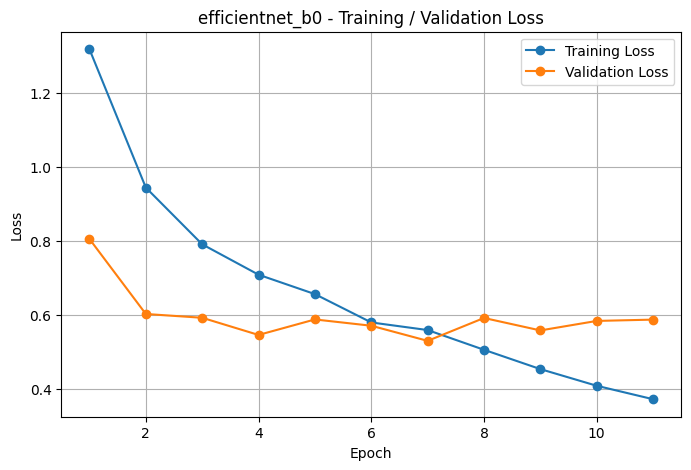


🛑 Early Stopping devreye girdi.
Validation loss iyileşmediği için eğitim erken durduruldu.

✅ Eğitim tamamlandı.
En iyi Validation Loss: 0.5302
En iyi model: ./checkpoints/efficientnet_b0_best_model.pth
Son checkpoint: ./checkpoints/efficientnet_b0_last_checkpoint.pth


In [60]:
efficientnet_model, eff_train_losses, eff_val_losses = train_model(
    model=efficientnet_model,
    model_name="efficientnet_b0",
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    device=device,
    num_epochs=15,
    learning_rate=1e-4,
    early_stopping_patience=4,
    resume=False
)

Model: resnet50
Epoch: 10/15
Train Loss : 0.3335
Val Loss   : 0.6461
Val Accuracy: 0.7951
Learning Rate: 0.0000500
Early Stopping sayacı: 4/4


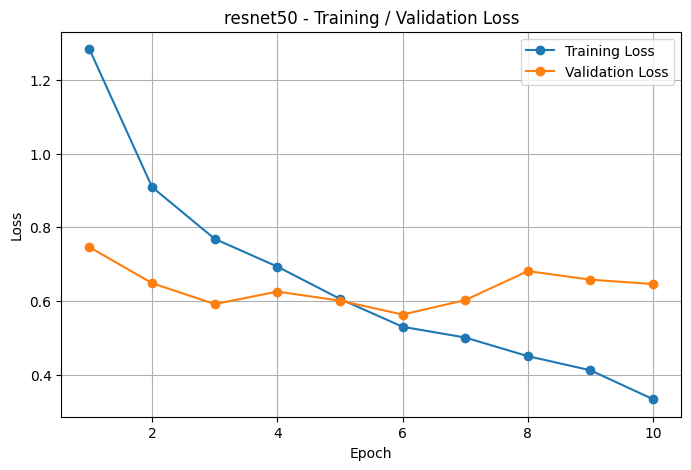


🛑 Early Stopping devreye girdi.
Validation loss iyileşmediği için eğitim erken durduruldu.

✅ Eğitim tamamlandı.
En iyi Validation Loss: 0.5634
En iyi model: ./checkpoints/resnet50_best_model.pth
Son checkpoint: ./checkpoints/resnet50_last_checkpoint.pth


In [61]:
resnet50_model, resnet_train_losses, resnet_val_losses = train_model(
    model=resnet50_model,
    model_name="resnet50",
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    device=device,
    num_epochs=15,
    learning_rate=1e-4,
    early_stopping_patience=4,
    resume=False
)

Model: baseline_cnn
Epoch: 5/15
Train Loss : 1.3571
Val Loss   : 0.9756
Val Accuracy: 0.5847
Learning Rate: 0.0000500
Early Stopping sayacı: 4/4


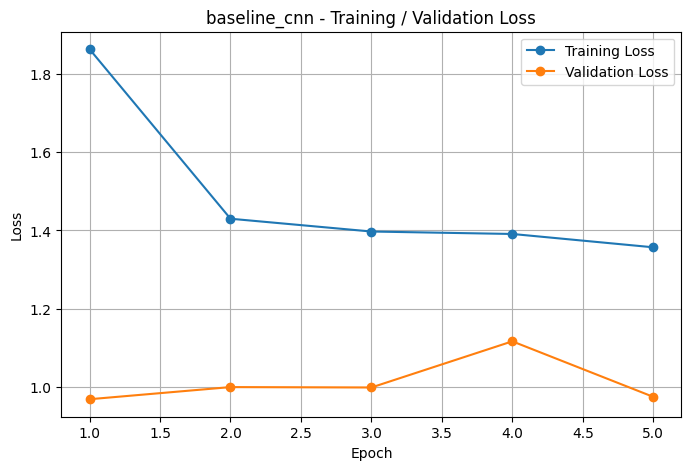


🛑 Early Stopping devreye girdi.
Validation loss iyileşmediği için eğitim erken durduruldu.

✅ Eğitim tamamlandı.
En iyi Validation Loss: 0.9695
En iyi model: ./checkpoints/baseline_cnn_best_model.pth
Son checkpoint: ./checkpoints/baseline_cnn_last_checkpoint.pth


In [62]:
baseline_model = BaselineCNN(
    num_classes=5
).to(device)

baseline_model, baseline_train_losses, baseline_val_losses = train_model(
    model=baseline_model,
    model_name="baseline_cnn",
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    device=device,
    num_epochs=15,
    learning_rate=1e-4,
    early_stopping_patience=4,
    resume=False
)

Baseline modelinizin saf (unweighted) başarısını ölçmek

In [64]:
criterion_unweighted = torch.nn.CrossEntropyLoss()
print("✅ Weighted Cross-Entropy Loss ve Unweighted Cross-Entropy Loss hazır.")

✅ Weighted Cross-Entropy Loss ve Unweighted Cross-Entropy Loss hazır.


# Alternatif Modeller

## Katman dondurma (Layer Freezing), sadece eğitilebilir parametreleri optimizatöre verme ve ReduceLROnPlateau scheduler mekanizması

Bu Düzenlemeden Sonra Ne Değişti?
Model Koruma (Freezing): Başlangıçta ana gövde dondurulduğu için modeller ImageNet'teki yeteneklerini kaybetmez ve ilk epoch'larda hızlı bir ezberleme (overfitting) yaşamaz.

Akıllı Optimizasyon: filter(lambda p: p.requires_grad, ...) yapısı sayesinde optimizer yalnızca son katmandaki güncellenebilir ağırlıklarla ilgilenir.

Dinamik Öğrenme: Tanımlanan ReduceLROnPlateau nesneleri ile eğitim sırasında val_loss tıkanırsa öğrenme hızı otomatik olarak aşağı çekilir.

In [37]:
# ============================================================
# EfficientNet-B0 + ResNet50
# 5 sınıfa uyarlama + Weighted Cross-Entropy + Layer Freezing + Scheduler
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights,
    resnet50,
    ResNet50_Weights
)

# Cihaz (Mac M2 için MPS desteğini koruyoruz)
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

NUM_CLASSES = 5

print("Kullanılan cihaz:", device)


# ============================================================
# 1. SINIF AĞIRLIKLARINI HESAPLA
# ============================================================

class_counts = (
    df_train["diagnosis"]
    .value_counts()
    .reindex(range(NUM_CLASSES), fill_value=0)
    .sort_index()
)

print("\nTrain sınıf dağılımı:")
print(class_counts)

total_samples = class_counts.sum()

class_weights = (
    total_samples /
    (NUM_CLASSES * class_counts.values)
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("\nSınıf ağırlıkları:")
for i, weight in enumerate(class_weights):
    print(f"Evre {i}: {weight.item():.4f}")


# ============================================================
# 2. WEIGHTED CROSS-ENTROPY LOSS
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print("\n✅ Weighted Cross-Entropy Loss hazır.")


# ============================================================
# 3. EFFICIENTNET-B0 (Freezing + Optimizer + Scheduler)
# ============================================================

efficientnet_model = efficientnet_b0(
    weights=EfficientNet_B0_Weights.DEFAULT
)

# 🌟 Layer Freezing: Tüm gövdeyi dondur (Önceki bilgileri korumak için)
for param in efficientnet_model.parameters():
    param.requires_grad = False

# Son katmanı 5 sınıfa çevir (Bu katman otomatik olarak requires_grad = True olur)
efficientnet_in_features = (
    efficientnet_model.classifier[1].in_features
)
efficientnet_model.classifier[1] = nn.Linear(
    efficientnet_in_features,
    NUM_CLASSES
)

efficientnet_model = efficientnet_model.to(device)

# 🌟 Sadece eğitilebilir (requires_grad=True olan) parametreleri optimize et
efficientnet_optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, efficientnet_model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

# 🌟 Learning Rate Scheduler
efficientnet_scheduler = ReduceLROnPlateau(
    efficientnet_optimizer, mode='min', patience=2, factor=0.5
)

print("✅ EfficientNet-B0 hazır (Freezing ve Scheduler aktif): çıktı sınıfı = 5")


# ============================================================
# 4. RESNET50 (Freezing + Optimizer + Scheduler)
# ============================================================

resnet50_model = resnet50(
    weights=ResNet50_Weights.DEFAULT
)

# 🌟 Layer Freezing: Tüm gövdeyi dondur
for param in resnet50_model.parameters():
    param.requires_grad = False

# Son katmanı 5 sınıfa çevir
resnet_in_features = resnet50_model.fc.in_features
resnet50_model.fc = nn.Linear(
    resnet_in_features,
    NUM_CLASSES
)

resnet50_model = resnet50_model.to(device)

# 🌟 Sadece eğitilebilir parametreler için optimizer
resnet_optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, resnet50_model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

# 🌟 Learning Rate Scheduler
resnet_scheduler = ReduceLROnPlateau(
    resnet_optimizer, mode='min', patience=2, factor=0.5
)

print("✅ ResNet50 hazır (Freezing ve Scheduler aktif): çıktı sınıfı = 5")

Kullanılan cihaz: mps

Train sınıf dağılımı:
diagnosis
0    1434
1     300
2     808
3     154
4     234
Name: count, dtype: Int64

Sınıf ağırlıkları:
Evre 0: 0.4086
Evre 1: 1.9533
Evre 2: 0.7252
Evre 3: 3.8052
Evre 4: 2.5043

✅ Weighted Cross-Entropy Loss hazır.
✅ EfficientNet-B0 hazır (Freezing ve Scheduler aktif): çıktı sınıfı = 5
✅ ResNet50 hazır (Freezing ve Scheduler aktif): çıktı sınıfı = 5


## BaselineCNN: Sıfırdan (from scratch) eğitildiği için önceden öğrenilmiş bir örüntüye sahip değildir. Bu modelde ezberlemeyi engellemek için mimarinin içine Dropout katmanları eklemek ve weight_decay parametresini artırmak en etkili çözümdür.

BaselineCNN mimarinizde aşırı öğrenmeyi (overfitting) engellemek ve sıfırdan eğitimin dezavantajlarını dengelemek için iki temel değişiklik yaptık:

Dropout Katmanı Eklendi: Sınıflandırma bölümündeki tam bağlı (Linear) katmanların arasına nn.Dropout(p=0.5) yerleştirilerek eğitim sırasında nöronların rastgele kapatılması sağlandı, böylece modelin veriyi ezberlemesinin önüne geçildi.

Weight Decay (Ağırlık Sönümleme) Artırıldı: Optimizatör tarafında weight_decay=1e-3 parametresi kullanılarak büyük ağırlık cezaları uygulandı ve model katsayılarının aşırı büyümesi engellendi.

In [38]:
import torch
import torch.nn as nn
import torch.optim as optim

# ============================================================
# 1. DROPOUT İLE GÜNCELLENMİŞ BASELINECNN
# ============================================================

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=5, dropout_p=0.5):
        super(BaselineCNN, self).__init__()

        # Özellik Çıkarma Katmanları (Feature Extractor)
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        # Sınıflandırma Katmanları (Classifier)
        # 224x224 boyutundaki resim 3 kez maxpool sonrası 28x28 olur (128 kanal)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),  # 🌟 Aşırı öğrenmeyi önlemek için Dropout
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Modeli oluşturma ve cihaza taşıma
baseline_model = BaselineCNN(num_classes=5, dropout_p=0.5).to(device)

In [39]:
# ============================================================
# 2. ARTIRILMIŞ WEIGHT_DECAY İLE OPTİMİZATÖR
# ============================================================

# Sıfırdan eğitilen BaselineCNN için ağırlıkların aşırı büyüyüp
# ezber yapmasını engellemek adına weight_decay değeri artırılır (örn: 1e-3)
baseline_optimizer = optim.AdamW(
    baseline_model.parameters(),
    lr=1e-4,
    weight_decay=1e-3  # 🌟 Ağırlık cezası artırıldı
)

print("✅ Dropout katmanlı BaselineCNN ve artırılmış Weight Decay hazır.")

✅ Dropout katmanlı BaselineCNN ve artırılmış Weight Decay hazır.


## Yeni model testleri

In [40]:
def evaluate_model(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    print(f"Test Doğruluğu (Accuracy): %{accuracy * 100:.2f}")
    return accuracy

### Başarı Metrikleri

In [41]:
from sklearn.metrics import cohen_kappa_score, f1_score, classification_report
import torch

def evaluate_model_advanced(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    # Metriklerin hesaplanması
    accuracy = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    f1 = f1_score(all_labels, all_preds, average='weighted')

    print(f"Test Doğruluğu (Accuracy): %{accuracy * 100:.2f}")
    print(f"Quadratic Weighted Kappa (QWK): {qwk:.4f}")
    print(f"Weighted F1-Score: {f1:.4f}")

    print("\nSınıf Bazlı Detaylı Rapor:")
    print(classification_report(all_labels, all_preds))

    return qwk, f1

In [42]:
print("--- Baseline CNN Sonuçları ---")
evaluate_model_advanced(baseline_model, test_loader, device)

print("\n--- ResNet50 Sonuçları ---")
evaluate_model_advanced(resnet50_model, test_loader, device)

print("\n--- EfficientNet-B0 Sonuçları ---")
evaluate_model_advanced(efficientnet_model, test_loader, device)

--- Baseline CNN Sonuçları ---
Test Doğruluğu (Accuracy): %38.52
Quadratic Weighted Kappa (QWK): 0.0983
Weighted F1-Score: 0.3589

Sınıf Bazlı Detaylı Rapor:
              precision    recall  f1-score   support

           0       0.62      0.62      0.62       199
           1       0.00      0.00      0.00        30
           2       0.00      0.00      0.00        87
           3       0.10      0.18      0.13        17
           4       0.10      0.42      0.16        33

    accuracy                           0.39       366
   macro avg       0.17      0.24      0.18       366
weighted avg       0.35      0.39      0.36       366


--- ResNet50 Sonuçları ---


/Users/cerenkocabas/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/cerenkocabas/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/cerenkocabas/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to c

Test Doğruluğu (Accuracy): %13.39
Quadratic Weighted Kappa (QWK): 0.1735
Weighted F1-Score: 0.0815

Sınıf Bazlı Detaylı Rapor:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       199
           1       0.08      0.47      0.14        30
           2       0.22      0.34      0.27        87
           3       0.09      0.29      0.14        17
           4       0.00      0.00      0.00        33

    accuracy                           0.13       366
   macro avg       0.08      0.22      0.11       366
weighted avg       0.06      0.13      0.08       366


--- EfficientNet-B0 Sonuçları ---


/Users/cerenkocabas/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/cerenkocabas/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/cerenkocabas/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to c

Test Doğruluğu (Accuracy): %18.31
Quadratic Weighted Kappa (QWK): 0.0392
Weighted F1-Score: 0.0987

Sınıf Bazlı Detaylı Rapor:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       199
           1       0.00      0.00      0.00        30
           2       0.24      0.64      0.35        87
           3       0.10      0.12      0.11        17
           4       0.08      0.27      0.13        33

    accuracy                           0.18       366
   macro avg       0.08      0.21      0.12       366
weighted avg       0.07      0.18      0.10       366



/Users/cerenkocabas/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/cerenkocabas/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/cerenkocabas/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to c

(np.float64(0.03919708349804529), 0.09865137951131624)